# Hacia una medicina preventiva en hipertensión arterial

La hipertensión arterial es uno de los principales factores de riesgo para las enfermedades cardiovasculares, las cuales, a su vez, son una de las causas principales de morbilidad y mortalidad a nivel mundial. La detección temprana de esta afección representa un gran reto, ya que sus síntomas a menudo pasan desapercibidos y el diagnóstico se realiza con frecuencia en etapas avanzadas. Esta situación resalta la importancia de encontrar soluciones que apoyen en la identificación precoz de la hipertensión.

Este proyecto tiene como objetivo desarrollar modelos predictivos basados en datos que permitan estimar el riesgo de hipertensión en pacientes. La finalidad es doble: por un lado, facilitar la identificación temprana de casos y, por otro, identificar los factores clave que influyen en el desarrollo de la enfermedad. Una herramienta de este tipo sería de gran valor para los profesionales de la salud ya que les permitiría fortalecer las campañas y programas de prevención, así como diseñar estrategias de educación en salud más personalizadas.

## Objetivos

- Aplicar técnicas de clasificación basadas en árboles de decisión y K-vecinos más cercanos para construir modelos predictivos que permitan identificar el riesgo de desarrollar hipertensión.
- Identificar los factores más relevantes que influyen en el desarrollo de la hipertensión a partir del análisis de los datos.

# 1. Exploración y Perfilamiento de Datos

Exploración y perfilamiento de los datos, utilizando las funcionalidades de la librería pandas. Recuerda que este paso es muy importante para determinar problemas de calidad (por ejemplo, valores ausentes y registros duplicados) y tomar decisiones relacionadas con la preparación de los datos para el algoritmo de aprendizaje.

## Carga de datos

Se carga el conjunto de datos desde el archivo CSV utilizando codificación latin-1 y delimitador punto y coma. Se visualizan las primeras filas para verificar la estructura del dataset.

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [61]:
data_raw = pd.read_csv("../../data/stage-2/Datos_hipertension.csv", encoding='latin-1', delimiter=';')
data_raw.head()

,Edad,Ingesta_Sal,Nivel_Stres,Colesterol,Duración_Sueño,BMI,Medicación,Historia_Familiar,Actividad_Fisica,Fumador,Glucosa,Enfermedad_Corazon,Hipertension
0,69,8.0,9,242.4,6.4,25.8,Ninguna,Si,Baja,No,127.8,Si,Si
1,32,11.7,10,177.2,5.4,23.4,Ninguna,No,Baja,No,105.9,No,No
2,78,9.5,3,193.0,7.1,18.7,Ninguna,No,Moderada,No,102.7,No,No
3,38,10.0,10,268.1,4.2,22.1,InhibidorACE,No,Baja,No,99.0,No,Si
4,41,9.8,1,175.3,5.8,16.2,Otro,No,Moderada,No,101.5,No,No


## Dimensiones del dataset

Se verifican las dimensiones del conjunto de datos para conocer el número de registros y variables. El dataset contiene 1990 registros y 13 variables.

In [62]:
data_raw.shape

(1990, 13)

## Información general

Se examina la estructura del dataset, incluyendo tipos de datos y valores no nulos. Todas las columnas contienen 1990 valores no nulos, indicando que no hay valores faltantes en el dataset.

In [63]:
data_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1990 entries, 0 to 1989
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Edad                1990 non-null   int64  
 1   Ingesta_Sal         1990 non-null   float64
 2   Nivel_Stres         1990 non-null   int64  
 3   Colesterol          1990 non-null   float64
 4   Duración_Sueño      1990 non-null   float64
 5   BMI                 1990 non-null   float64
 6   Medicación          1990 non-null   str    
 7   Historia_Familiar   1990 non-null   str    
 8   Actividad_Fisica    1990 non-null   str    
 9   Fumador             1990 non-null   str    
 10  Glucosa             1990 non-null   float64
 11  Enfermedad_Corazon  1990 non-null   str    
 12  Hipertension        1990 non-null   str    
dtypes: float64(5), int64(2), str(6)
memory usage: 202.2 KB


## Estadísticas descriptivas

Se calculan las estadísticas descriptivas de las variables numéricas para identificar valores extremos y distribución de los datos. Se observan posibles valores atípicos en variables como Colesterol y Duración_Sueño.

In [64]:
data_raw.describe()

,Edad,Ingesta_Sal,Nivel_Stres,Colesterol,Duración_Sueño,BMI,Glucosa
count,1990.000000,1990.000000,1990.000000,1990.000000,1990.000000,1990.000000,1990.000000
mean,50.379397,8.531608,4.974372,209.526935,6.452613,26.013869,105.642211
std,19.439669,1.994245,3.144396,75.791456,1.540354,4.507425,22.541122
min,18.000000,2.500000,0.000000,121.200000,1.500000,11.900000,70.000000
25%,34.000000,7.200000,2.000000,181.325000,5.400000,23.000000,89.200000
50%,50.000000,8.500000,5.000000,204.400000,6.500000,25.900000,102.500000
75%,67.000000,9.900000,8.000000,231.700000,7.500000,29.100000,119.875000
max,84.000000,16.400000,10.000000,2360.000000,11.400000,41.900000,196.100000


## Detección y eliminación de duplicados

Se identifican y eliminan registros duplicados del dataset. Se encontraron 4 registros duplicados que fueron eliminados exitosamente.

In [65]:
before_drop = data_raw.duplicated().sum()
data = data_raw.drop_duplicates()
after_drop = data.duplicated().sum()
print(f"Before dropping duplicates: {before_drop},", f"After dropping duplicates: {after_drop}")

Before dropping duplicates: 4, After dropping duplicates: 0


## Verificación de valores faltantes

Se verifica la presencia de valores ausentes en cada columna del dataset. No se encontraron valores faltantes en ninguna variable.

In [66]:
data_raw.isnull().sum()

Edad                  0
Ingesta_Sal           0
Nivel_Stres           0
Colesterol            0
Duración_Sueño        0
BMI                   0
Medicación            0
Historia_Familiar     0
Actividad_Fisica      0
Fumador               0
Glucosa               0
Enfermedad_Corazon    0
Hipertension          0
dtype: int64

## Detección visual de outliers

Se generan gráficos de caja para identificar visualmente la presencia de valores atípicos en las variables numéricas. Los gráficos revelan la presencia de valores atípicos en las variables Ingesta_Sal, Colesterol, Duración_Sueño, BMI y Glucosa.

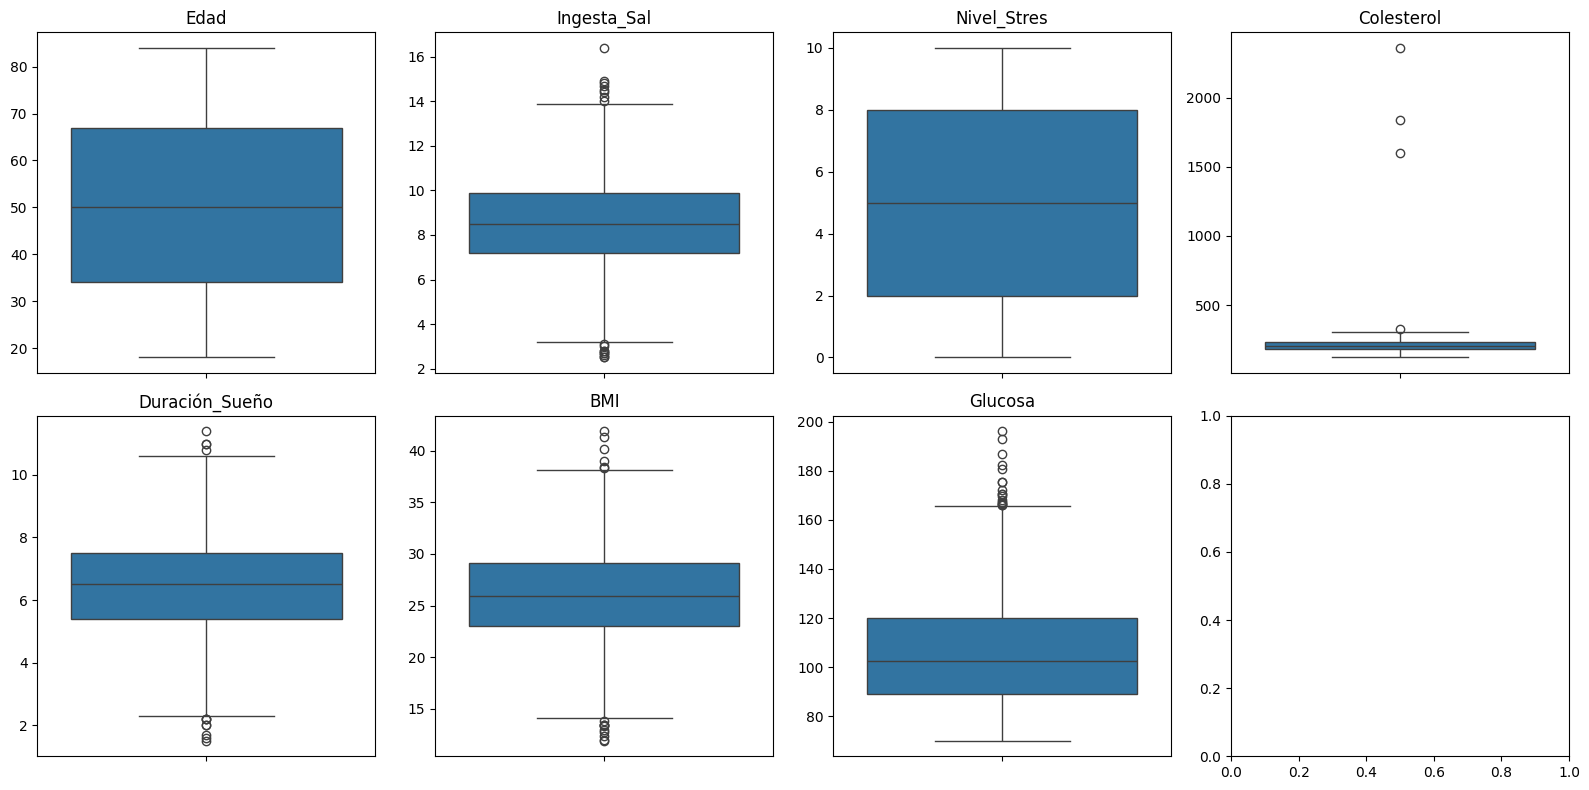

In [67]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

columnas = ['Edad', 'Ingesta_Sal', 'Nivel_Stres', 'Colesterol', 
            'Duración_Sueño', 'BMI', 'Glucosa']

for i, col in enumerate(columnas):
    sns.boxplot(y=data_raw[col], ax=axes[i])
    axes[i].set_title(f'{col}')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

# Conclusiones de la Exploración de Datos

## Resumen General

El dataset de hipertensión contiene 1990 registros con 13 variables (7 numéricas y 6 categóricas). El análisis exploratorio revela un conjunto de datos en buen estado general.

## Calidad de los Datos

### Valores Faltantes
No se identificaron valores faltantes en ninguna variable.

### Registros Duplicados
Se detectaron y eliminaron 4 registros duplicados (0.3% del dataset).

## Valores Atípicos

Se identificaron outliers en cinco variables numéricas:

- **Colesterol**: Valor máximo de 2360 mg/dL, muy por encima del percentil 75 (231.7 mg/dL)
- **Ingesta_Sal**: Máximo de 16.4 g/día vs percentil 75 de 9.9 g/día
- **Duración_Sueño**: Valores extremos entre 1.5 y 11.4 horas
- **BMI**: Outliers en ambos extremos del rango
- **Glucosa**: Valores elevados que requieren evaluación

## Estado del Dataset

El dataset presenta buena calidad con estructura completa y sin valores faltantes. Los principales aspectos a considerar en la preparación de datos son:

- Tratamiento de valores atípicos en variables numéricas
- Codificación de las 6 variables categóricas
- Normalización o estandarización de variables numéricas
- División apropiada entre entrenamiento y prueba

# 2. Construcción del pipeline de limpieza y preparación de los datos

Construcción del pipeline de limpieza y preparación de los datos, justificando las decisiones tomadas con base en los resultados obtenidos en el paso anterior.

In [68]:
train, test = train_test_split(data, test_size=0.2, random_state=77)
train.head()

,Edad,Ingesta_Sal,Nivel_Stres,Colesterol,Duración_Sueño,BMI,Medicación,Historia_Familiar,Actividad_Fisica,Fumador,Glucosa,Enfermedad_Corazon,Hipertension
1444,37,6.7,3,194.7,8.6,21.1,BloqueadorBeta,No,Alta,No,70.0,No,No
1917,34,9.9,2,192.8,4.8,21.4,InhibidorACE,No,Baja,Si,105.7,No,No
342,75,7.3,2,209.4,5.9,35.2,Ninguna,Si,Alta,No,131.7,No,Si
740,50,6.8,7,213.3,4.5,22.5,BloqueadorBeta,Si,Moderada,No,117.2,No,No
1706,49,6.5,0,189.8,5.7,21.0,Ninguna,No,Moderada,Si,132.3,No,No


In [69]:
x_train = train.drop('Hipertension', axis=1)
y_train = train['Hipertension']

In [70]:
numeric_features = list(x_train.select_dtypes(include=['int64', 'float64']).columns)
categorical_features = list(x_train.select_dtypes(exclude=['int64', 'float64']).columns)

print(f"Numeric features:\n{numeric_features}")
print(f"\nCategorical features:\n{categorical_features}")

Numeric features:
['Edad', 'Ingesta_Sal', 'Nivel_Stres', 'Colesterol', 'Duración_Sueño', 'BMI', 'Glucosa']

Categorical features:
['Medicación', 'Historia_Familiar', 'Actividad_Fisica', 'Fumador', 'Enfermedad_Corazon']


In [71]:
numeric_transformer = RobustScaler()
categorical_transformer = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

In [74]:
encoder = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

steps = [
    ('encoder', encoder),
]